In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/content/marketing_campaign_data_messy.csv')
print(f"rows: {df.shape[0]}, columns: {df.shape[1]}")

rows: 2020, columns: 12


In [3]:
df

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,$102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA
...,...,...,...,...,...,...,...,...,...,...,...,...
2015,CMP-00400,Q3_Summer_CMP-00400,2023-10-31 00:00:00,2023-11-13,TikTok,30592,586,$503.95,77.0,1,NaN,TI
2016,CMP-01255,Q4_Summer_CMP-01255,2023-09-01 00:00:00,2023-09-26,Google Ads,20097,897,1641.0,162.0,0,NaN,GO
2017,CMP-01050,Q2_Launch_CMP-01050,2023-02-09 00:00:00,2023-02-21,Instagram,33254,1117,883.82,214.0,0,NaN,IN
2018,CMP-01118,Q4_Winter_CMP-01118,2023-03-30 00:00:00,2023-04-27,Facebook,68728,2960,4198.5,591.0,Yes,NaN,FA


In [4]:
print(df.columns)




Index([' Campaign_ID ', 'Campaign_Name', 'Start_Date', 'End_Date', 'Channel',
       'Impressions', 'Clicks ', 'Spend', 'Conversions', 'Active', 'Clicks',
       'Campaign_Tag'],
      dtype='object')


In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns)

Index(['campaign_id', 'campaign_name', 'start_date', 'end_date', 'channel',
       'impressions', 'clicks', 'spend', 'conversions', 'active', 'clicks',
       'campaign_tag'],
      dtype='object')


In [6]:

print(df['spend'].head(3))

df['spend'] = df['spend'].astype(str).str.replace(r'[^\d.-]', '',regex = True).astype(float)
print('FIXED')
print(df['spend'].head(3))

0    $102.82
1      24.33
2    1323.39
Name: spend, dtype: object
FIXED
0     102.82
1      24.33
2    1323.39
Name: spend, dtype: float64


In [7]:
##CATEGPROCAL TYPOS

print(df["channel"].unique())

cleanup = {
    'Facebok':'Facebook',
    'Insta_gram':'Instagram',
    'E-mail':'Email',
    'Tik_Tok':'TikTok',
    'Gogle':'Google Ads',
    'N/A':np.nan
}

df["channel"] = df["channel"].replace(cleanup)
print('FIXED')
print(df["channel"].unique())

['TikTok' 'Facebook' 'Email' 'Instagram' 'Google Ads' 'E-mail' nan 'Gogle'
 'Tik_Tok' 'Facebok' 'Insta_gram']
FIXED
['TikTok' 'Facebook' 'Email' 'Instagram' 'Google Ads' nan]


In [8]:
### BOOLEAN FIX

print(df['active'].unique())

cleanup_BOOL = {
    'Y' : 1,
    'No' : 0,
    '0' : 0,
    'True': 1,
    'Yes': 1,
    '1': 1,
    'False': 0

}

df['active'] = df['active'].replace(cleanup_BOOL)
print("FIXED")
print(df['active'].unique())



['Y' '0' 'No' 'True' 'Yes' '1' 'False']
FIXED
[1 0]


/tmp/ipykernel_7150/3487336576.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['active'] = df['active'].replace(cleanup_BOOL)


In [9]:
##START DATE FIX

print(df['start_date'].head(4))
df['start_date'] = df['start_date'].astype(str).str.replace('00:00:00', '')


print('SEMI FIXED')
print(df['start_date'].head(4))
df['start_date'] = pd.to_datetime(df['start_date'], format= 'mixed',dayfirst= True)

print('FIXED')
print(df['start_date'].head(4))




0    2023-11-24 00:00:00
1    2023-05-06 00:00:00
2    2023-12-13 00:00:00
3             2023-10-30
Name: start_date, dtype: object
SEMI FIXED
0    2023-11-24 
1    2023-05-06 
2    2023-12-13 
3     2023-10-30
Name: start_date, dtype: object
FIXED
0   2023-11-24
1   2023-06-05
2   2023-12-13
3   2023-10-30
Name: start_date, dtype: datetime64[ns]


In [10]:

print(df['end_date'].head(4))
df['end_date'] = pd.to_datetime(df['end_date'], format= '%Y-%m-%d',errors='coerce')

print('FIXED')
print(df['end_date'].head(4))

0    2023-12-13
1    2023-05-12
2    2023-12-20
3    2023-11-03
Name: end_date, dtype: object
FIXED
0   2023-12-13
1   2023-05-12
2   2023-12-20
3   2023-11-03
Name: end_date, dtype: datetime64[ns]


In [11]:
# delete the duplicate NA variable

df = df.loc[:, ~df.columns.duplicated()]
print(df.columns)

Index(['campaign_id', 'campaign_name', 'start_date', 'end_date', 'channel',
       'impressions', 'clicks', 'spend', 'conversions', 'active',
       'campaign_tag'],
      dtype='object')


In [12]:
#check if clicks is greater than impressions

check = df['clicks']> df['impressions']
print(df.loc[check ,["clicks", "impressions"]].head(3))

Empty DataFrame
Columns: [clicks, impressions]
Index: []


In [13]:
# time travel mask

time_check = df['start_date'] > df['end_date']
print(df.loc[time_check, ['start_date', 'end_date']].head(5))

df.loc[time_check, 'end_date'] = df.loc[time_check, 'start_date']+ pd.Timedelta(days=30)
print('FIXED')
print(df.loc[time_check, ['start_date', 'end_date']].head(5))

#its an ad campaign data and in this context the usual run of a campaigh is 30 days

   start_date   end_date
1  2023-06-05 2023-05-12
14 2023-10-02 2023-02-16
20 2023-09-07 2023-07-17
23 2023-06-05 2023-05-01
31 2023-07-05 2023-05-29
FIXED
   start_date   end_date
1  2023-06-05 2023-07-05
14 2023-10-02 2023-11-01
20 2023-09-07 2023-10-07
23 2023-06-05 2023-07-05
31 2023-07-05 2023-08-04


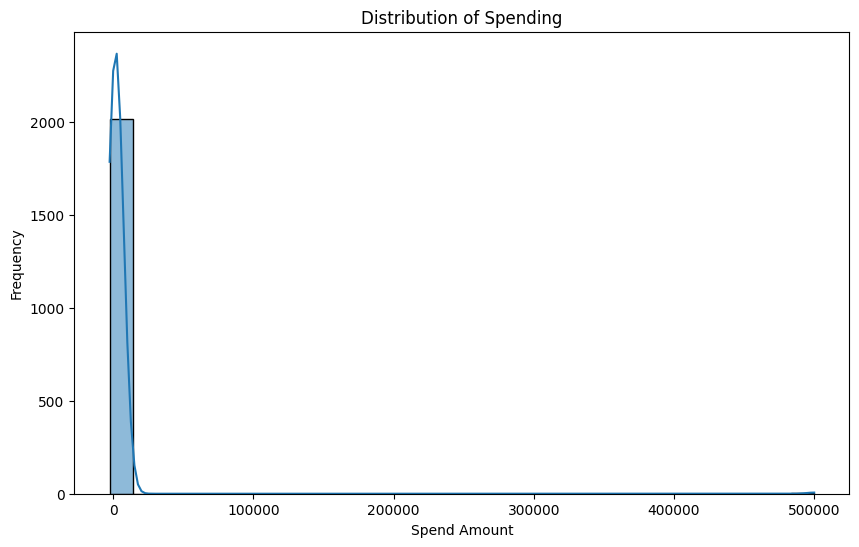

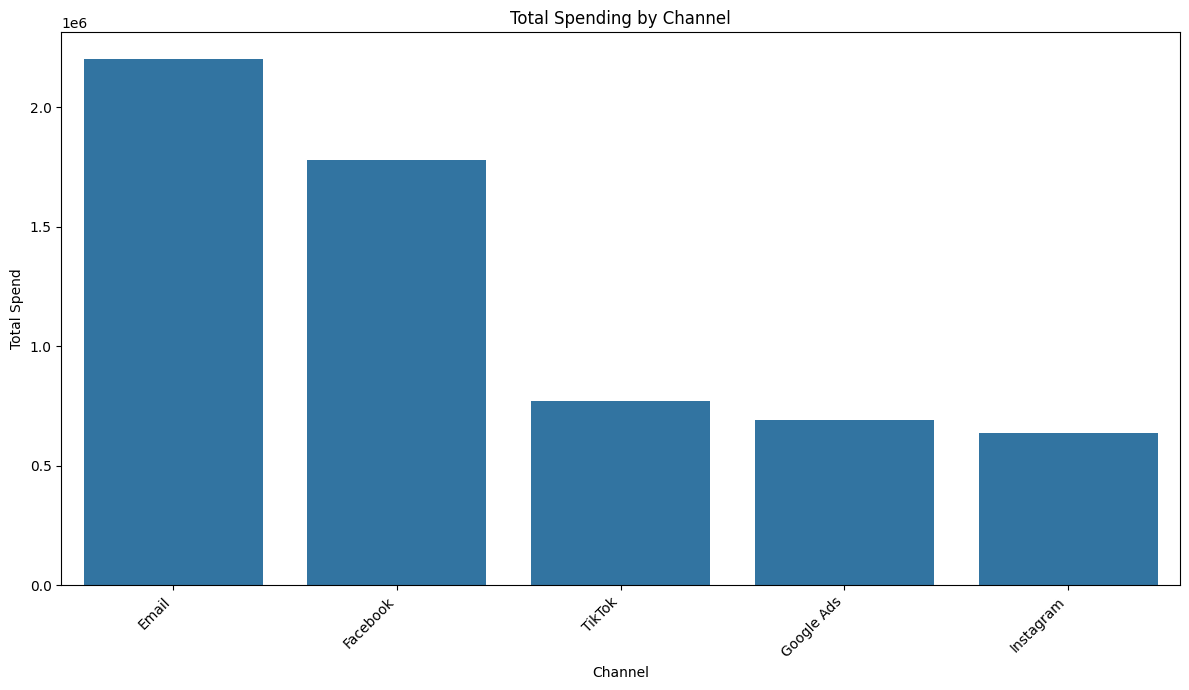

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of 'spend' to see the distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['spend'], bins=30, kde=True)
plt.title('Distribution of Spending')
plt.xlabel('Spend Amount')
plt.ylabel('Frequency')
plt.show()

# Bar chart of total spending by channel
plt.figure(figsize=(12, 7))
channel_spend = df.groupby('channel')['spend'].sum().sort_values(ascending=False)
sns.barplot(x=channel_spend.index, y=channel_spend.values)
plt.title('Total Spending by Channel')
plt.xlabel('Channel')
plt.ylabel('Total Spend')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
## GETTING RID OF EXTREME OUTLIERS

Q1 = df['spend'].quantile(0.25)
Q3 = df['spend'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (3*IQR)

outlier = df['spend'] > upper_bound
print(df.loc[outlier, ["campaign_id","spend"]].head(3))

print("with fix applied")

df.loc[outlier, 'spend'] = upper_bound
print(df.loc[outlier, ["campaign_id","spend"]].head(3))

     campaign_id      spend
789    CMP-00790  500000.00
1443   CMP-01444    8921.51
1460   CMP-01461  500000.00
with fix applied
     campaign_id      spend
789    CMP-00790  8603.5375
1443   CMP-01444  8603.5375
1460   CMP-01461  8603.5375


In [23]:
## FEATURE ENGINEERING

print(df['campaign_name'])

df["season"] = df['campaign_name'].str.extract(r'Q\d_([^_]+)_')

print("fix Applied")

print(df['season'].head(3))

0            Q4_Summer_CMP-00001
1            Q1_Launch_CMP-00002
2            Q3_Winter_CMP-00003
3       Q1_BlackFriday_CMP-00004
4            Q2_Winter_CMP-00005
                  ...           
2015         Q3_Summer_CMP-00400
2016         Q4_Summer_CMP-01255
2017         Q2_Launch_CMP-01050
2018         Q4_Winter_CMP-01118
2019         Q4_Launch_CMP-01554
Name: campaign_name, Length: 2020, dtype: object
fix Applied
0    Summer
1    Launch
2    Winter
Name: season, dtype: object
